In [1]:
# Sel 1: Import Library dan Redam Log
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.applications import EfficientNetB3
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# Sel 2: Konfigurasi Sumber Data
AUG_TRAIN_DIR = '../data/augmented/train/'
AUG_TEST_DIR = '../data/augmented/test/'
CLASSES = ['healthy', 'sick']
IMG_SIZE = 224

In [3]:
# Sel 3: Fungsi Load dan Preprocessing Gambar
def load_images_from_dir(base_dir):
    X, y = [], []
    for label_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(base_dir, class_name)
        for img_name in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, img_name))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img_resized / 255.0)
            y.append(label_idx)
    return np.array(X), np.array(y)

In [4]:
# Sel 4: Muat TRAIN (augmented) dan TEST (murni) secara terpisah
print("Memuat data TRAIN (hasil augmentasi)...")
X_train_raw, y_train = load_images_from_dir(AUG_TRAIN_DIR)
print(f"Total data train: {X_train_raw.shape[0]} gambar.")

print("\nMemuat data TEST (murni, tanpa augmentasi)...")
X_test_raw, y_test = load_images_from_dir(AUG_TEST_DIR)
print(f"Total data test: {X_test_raw.shape[0]} gambar.")

Memuat data TRAIN (hasil augmentasi)...
Total data train: 1120 gambar.

Memuat data TEST (murni, tanpa augmentasi)...
Total data test: 40 gambar.


In [5]:
# Sel 5: Ekstraksi Fitur via EfficientNet-B3 (terapkan SATU feature_extractor yang sama untuk train & test)
print("Membangun model EfficientNet-B3...")
feature_extractor = EfficientNetB3(weights='imagenet', include_top=False, pooling='avg')

print("Mengekstraksi fitur TRAIN...")
X_train_features = feature_extractor.predict(X_train_raw, batch_size=16)
print(f"Dimensi fitur train: {X_train_features.shape}")

print("Mengekstraksi fitur TEST...")
X_test_features = feature_extractor.predict(X_test_raw, batch_size=16)
print(f"Dimensi fitur test: {X_test_features.shape}")

Membangun model EfficientNet-B3...
Mengekstraksi fitur TRAIN...
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 497ms/step
Dimensi fitur train: (1120, 1536)
Mengekstraksi fitur TEST...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 596ms/step
Dimensi fitur test: (40, 1536)


In [6]:
# Sel 6: Normalisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [7]:
# Sel 7: Inisialisasi Model Klasifikasi Klasik
models = {
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='euclidean')
}


Training SVM (RBF) dengan Data Augmented (train) -> dievaluasi pada Test murni...


/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Akurasi: 0.8500
Macro F1-Score: 0.8496

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.90      0.86        20
        Sick       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



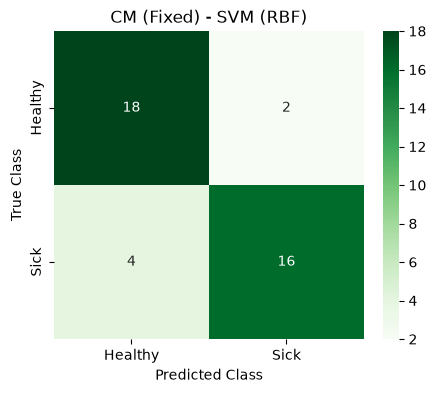

>>> Model SVM (RBF), Scaler, dan Feature Extractor berhasil disimpan! <<<

Training Random Forest dengan Data Augmented (train) -> dievaluasi pada Test murni...
Akurasi: 0.8500
Macro F1-Score: 0.8496

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.90      0.86        20
        Sick       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



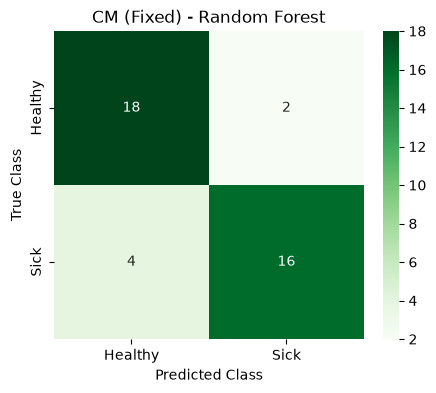


Training KNN dengan Data Augmented (train) -> dievaluasi pada Test murni...
Akurasi: 0.8000
Macro F1-Score: 0.8000

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80        20
        Sick       0.80      0.80      0.80        20

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



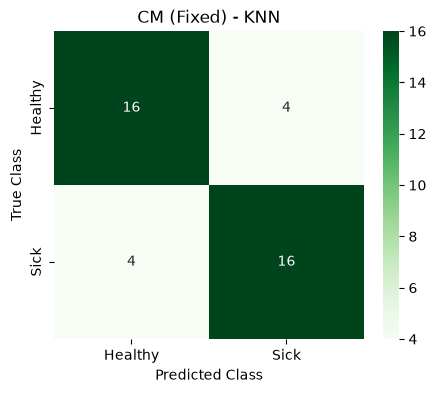

In [ ]:
# Sel 8: Pelatihan, Evaluasi, dan Penyimpanan Model
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name} dengan Data Augmented (train) -> dievaluasi pada Test murni...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1-Score: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sick']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Healthy', 'Sick'], yticklabels=['Healthy', 'Sick'])
    plt.title(f'CM (Fixed) - {name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

    if name == "SVM (RBF)":
        joblib.dump(model, '../models/svm_model_aug.pkl')
        joblib.dump(scaler, '../models/scaler_aug.pkl')
        feature_extractor.save('../models/efficientnet_extractor_aug.keras')
        print(f">>> Model {name}, Scaler, dan Feature Extractor berhasil disimpan! <<<")